In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from tqdm import tqdm
from pathlib import Path
import anndata as ad

In [2]:
# Load data, backed = r (read only) to save memory. 
# to not load the entire thing to ram and crash my cpu
input_path = "CMV_raw.h5ad"
adata = sc.read_h5ad(input_path, backed="r")
obs = adata.obs.copy()

Doing some exploration of data file

In [3]:
print("AnnData Object")
print(adata)
print("\n")

print("OBS (Cell Metadata) Info")
obs.info()
print("\n")

print("OBS Head")
print(obs.head())
print("\n")

print("Quick Categorical Value Counts (<50 unique)")
for col in obs.columns:
    if obs[col].nunique() < 50:
        print(f"\n[{col}]")
        print(obs[col].value_counts(dropna=False).head(10))

print("\nVAR (Gene Metadata) Head")
print(adata.var.head())

print("\nUnstructured Data Keys")
print(list(adata.uns.keys()) if adata.uns else "Empty")

AnnData Object
AnnData object with n_obs × n_vars = 3758514 × 18063 backed at 'CMV_raw.h5ad'
    obs: 'cohort.cohortGuid', 'subject.subjectGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'subject.ageAtFirstDraw', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'sample.visitName', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1', 'predicted_AIFI_L1', 'AIFI_L2', 'predicted_AIFI_L2', 'AIFI_L3', 'predicted_AIFI_L3', 'tissue_ontology_term_id', 'tissue_type', 'suspension_type', 'assay_ontology_term_id', 'sex_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', '

### Pre filter distribution

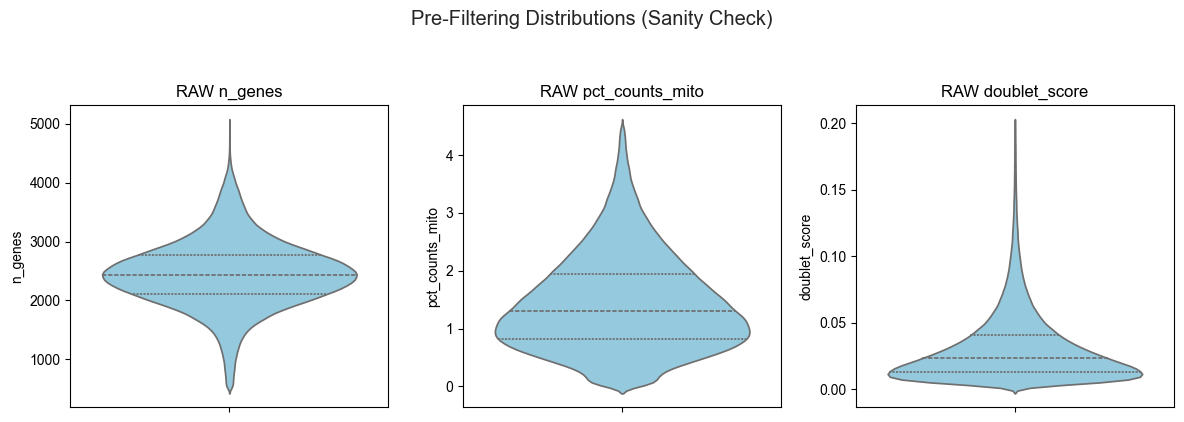

Raw Metadata Summary
          n_genes  pct_counts_mito  doublet_score
mean  2446.755808         1.445713       0.031387
50%   2437.000000         1.306018       0.023382
max   4998.000000         4.500000       0.199352


In [4]:
# Metrics we actually care about for filtering
metrics = ["n_genes", "pct_counts_mito", "doublet_score"]
pre_plot_df = obs[metrics].copy()

# Downsampling to 500k for performance
if len(pre_plot_df) > 500000:
    pre_plot_df = pre_plot_df.sample(500000, random_state=7)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.set_theme(style="whitegrid")

for i, metric in enumerate(metrics):
    sns.violinplot(y=pre_plot_df[metric], ax=axes[i], color="skyblue", inner="quartile")
    axes[i].set_title(f"RAW {metric}")
    
plt.suptitle("Pre-Filtering Distributions (Sanity Check)", y=1.05)
plt.tight_layout()
plt.show()

print("Raw Metadata Summary")
print(obs[metrics].describe().loc[['mean', '50%', 'max']])

### Apply QC Masks, Removing lower counts and filtering based on gene and cells

In [5]:
mask = pd.Series(True, index=obs.index)
start_n = len(obs)
print(f"Starting off with {start_n} total cells.")

# Ethnicity Filter
eth = obs["self_reported_ethnicity"].astype(str).str.strip().str.lower()
mask &= obs["self_reported_ethnicity"].notna() & (eth != "unknown")
print(f"Filtered out 'unknown' ethnicities... lost {start_n - mask.sum()} cells. {mask.sum()} left.")

prev_n = mask.sum()

# CMV Status Filter (Keep only definitive Positive/Negative)
mask &= obs["subject.cmv"].isin(["Positive", "Negative"])
print(f"Kept only Pos/Neg CMV cases. Lost another {prev_n - mask.sum()}. Down to {mask.sum()}.")

Starting off with 3758514 total cells.
Filtered out 'unknown' ethnicities... lost 2158196 cells. 1600318 left.
Kept only Pos/Neg CMV cases. Lost another 22381. Down to 1577937.


In [6]:
# Genes and Doublet Filter
prev_n = mask.sum()

mask &= obs["n_genes"] >= 1000
mask &= obs["n_genes"] <= 4500
print(f"Applying min 2000 genes cutoff: lost {prev_n - mask.sum()} cells. {mask.sum()} left.")

prev_n = mask.sum()

mask &= obs["doublet_score"].astype(float) < 0.13
print(f"Scrubbing doublets (score < 0.13): dropped {prev_n - mask.sum()} cells. {mask.sum()} remaining.")

# Mitochondrial filter
prev_n = mask.sum()
mask &= obs["pct_counts_mito"].astype(float) <= 4.0
print(f"Dropped {prev_n - mask.sum()} cells for high mito content.")

Applying min 2000 genes cutoff: lost 25100 cells. 1552837 left.
Scrubbing doublets (score < 0.13): dropped 15825 cells. 1537012 remaining.
Dropped 6559 cells for high mito content.


In [7]:
# checking cell type count after all QC to finally filter rare cell types
obs_before = obs.loc[mask].copy()
print(obs_before["cell_type"].value_counts().head(35))

cell_type
naive thymus-derived CD4-positive, alpha-beta T cell     281005
CD16-positive, CD56-dim natural killer cell, human       237759
effector memory CD8-positive, alpha-beta T cell          168911
effector memory CD4-positive, alpha-beta T cell          156780
CD14-positive, CD16-negative classical monocyte          115855
naive B cell                                             115693
central memory CD4-positive, alpha-beta T cell            90317
naive thymus-derived CD8-positive, alpha-beta T cell      80667
memory B cell                                             49945
CD4-positive, alpha-beta memory T cell                    34319
mature gamma-delta T cell                                 32873
memory regulatory T cell                                  32560
CD14-low, CD16-positive monocyte                          25673
mucosal invariant T cell                                  25603
CD16-negative, CD56-bright natural killer cell, human     14254
Be cell                       

In [8]:
# removing rare cell types
final_counts = obs.loc[mask, "cell_type"].value_counts()
keep_final_types = final_counts[final_counts >= 5000].index

prev_n = mask.sum()
mask &= obs["cell_type"].isin(keep_final_types)
print(f"Cleaned up {prev_n - mask.sum()} cells from types that became too rare after filtering.")

# Finalize the subset
obs_filtered = obs.loc[mask].copy()

print(f"\nFINAL SURVIVORS: {mask.sum()} / {start_n} ({mask.sum()/start_n*100:.1f}%)")

# Final Checks
print("\nFinal CMV Breakdown:")
print(obs_filtered["subject.cmv"].value_counts())

print("\nFinal Ethnicity Breakdown:")
print(obs_filtered["self_reported_ethnicity"].value_counts())

print("\nFinal Cell Type Breakdown (Top 20):")
print(obs_filtered["cell_type"].value_counts().head(20))

Cleaned up 19948 cells from types that became too rare after filtering.

FINAL SURVIVORS: 1510505 / 3758514 (40.2%)

Final CMV Breakdown:
subject.cmv
Positive     996424
Negative     514081
Equivocal         0
Name: count, dtype: int64

Final Ethnicity Breakdown:
self_reported_ethnicity
Asian                739827
Hispanic or Latin    514180
African American     174727
Native American       63760
Pacific Islander      18011
unknown                   0
Name: count, dtype: int64

Final Cell Type Breakdown (Top 20):
cell_type
naive thymus-derived CD4-positive, alpha-beta T cell     281005
CD16-positive, CD56-dim natural killer cell, human       237759
effector memory CD8-positive, alpha-beta T cell          168911
effector memory CD4-positive, alpha-beta T cell          156780
CD14-positive, CD16-negative classical monocyte          115855
naive B cell                                             115693
central memory CD4-positive, alpha-beta T cell            90317
naive thymus-derived CD

Post QC Visualize Metrics

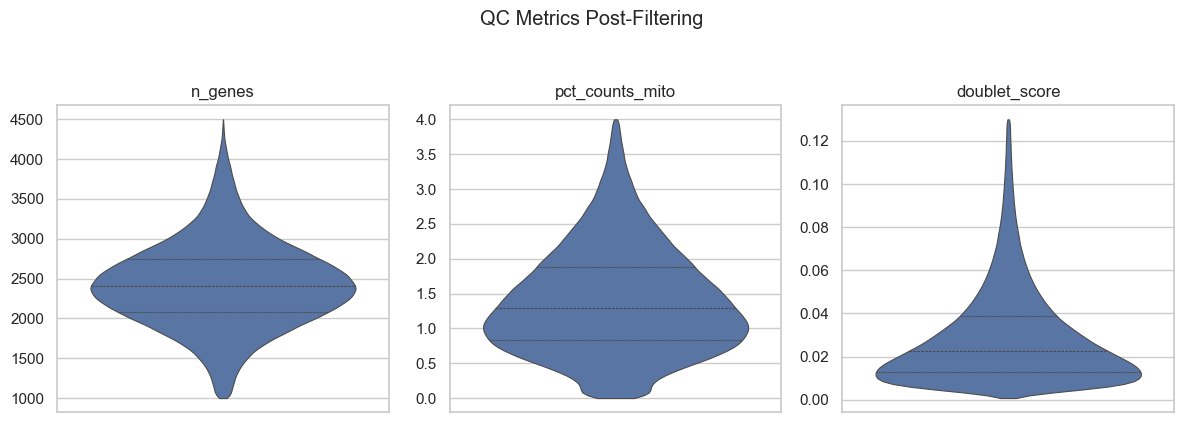

In [9]:
metrics = ["n_genes", "pct_counts_mito", "doublet_score"]
plot_df = obs_filtered[metrics].copy()

# Downsampling to 500k for performance
if len(plot_df) > 500000:
    plot_df = plot_df.sample(500000, random_state=7)

# Subplots for 3 metrics
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.set_theme(style="whitegrid")

for i, metric in enumerate(metrics):
    sns.violinplot(y=plot_df[metric], ax=axes[i], inner="quartile", cut=0, linewidth=0.8)
    axes[i].set_title(metric)
    axes[i].set_ylabel("")

plt.suptitle("QC Metrics Post-Filtering", y=1.05)
plt.tight_layout()
plt.show()

### Donor Split (Train/Val/Test : 70/15/15) based on donors

In [10]:
# 1. Get unique donors from your high-quality filtered set
donors = np.array(sorted(obs_filtered["donor_id"].dropna().unique()))
rng = np.random.default_rng(7)
rng.shuffle(donors)

# 2. Define the 70/15/15 split points
n_donors = len(donors)
train_n = int(np.floor(0.70 * n_donors))
val_n = int(np.floor(0.15 * n_donors))

train_donors = donors[:train_n]
val_donors = donors[train_n : train_n + val_n]
test_donors = donors[train_n + val_n :]

# 3. Create the mapping
split_map = {d: "train" for d in train_donors}
split_map.update({d: "val" for d in val_donors})
split_map.update({d: "test" for d in test_donors})

# 4. Map back to the filtered metadata first
obs_filtered["split"] = obs_filtered["donor_id"].map(split_map)

# 5. creating split
split_full = pd.Series("drop", index=obs.index)
split_full.loc[obs_filtered.index] = obs_filtered["split"]
print(split_full.value_counts())

drop     2248009
train     990955
val       261296
test      258254
Name: count, dtype: int64


#### Memory-Safe Gene Filtering

In [ ]:
# Gene Masking (Use the full filtered population to define features), ensuring we dont accidentally drop genes that are prevalent in Test/Val
all_filtered_mask = split_full.isin(["train", "val", "test"]).to_numpy()
cell_idx = np.flatnonzero(all_filtered_mask)
gene_counts = np.zeros(adata.n_vars, dtype=np.int64)

for start in tqdm(range(0, len(cell_idx), 50000), desc="Scanning for expressed genes"):
    idx = cell_idx[start : start + 50000]
    chunk = adata.X[idx, :] # This pulls from disk
    # Use a method that works regardless of sparse/dense chunking
    gene_counts += np.asarray((chunk > 0).sum(axis=0)).ravel()

gene_mask = gene_counts >= 100
print(f"Genes passing threshold: {gene_mask.sum()} / {adata.n_vars}")

# Extract cells safely into memory in contiguous chunks to bypass HDF5 hyperslabbing memory crash
train_chunks, val_chunks, test_chunks = [], [], []

train_mask = (split_full == "train").to_numpy()
val_mask = (split_full == "val").to_numpy()
test_mask = (split_full == "test").to_numpy()

for start in tqdm(range(0, adata.n_obs, 50000), desc="Building Data Splits"):
    end = min(start + 50000, adata.n_obs)
    
    # Read a continuous block from disk
    chunk = adata.X[start:end]
    if not sparse.issparse(chunk):
        chunk = sparse.csr_matrix(chunk)
        
    # Apply the gene mask to the chunk immediately to save RAM
    chunk = chunk[:, gene_mask]
    
    # Slice the corresponding labels for this block
    t_mask = train_mask[start:end]
    v_mask = val_mask[start:end]
    te_mask = test_mask[start:end]
    
    # Append the surviving cells to our lists
    if t_mask.sum() > 0: train_chunks.append(chunk[t_mask])
    if v_mask.sum() > 0: val_chunks.append(chunk[v_mask])
    if te_mask.sum() > 0: test_chunks.append(chunk[te_mask])

# Glue the chunks together vertically
X_train = sparse.vstack(train_chunks)
X_val = sparse.vstack(val_chunks)
X_test = sparse.vstack(test_chunks)

# Reconstruct the clean AnnData objects strictly in memory
train_adata = ad.AnnData(X=X_train, obs=adata.obs[train_mask].copy(), var=adata.var[gene_mask].copy())
val_adata = ad.AnnData(X=X_val, obs=adata.obs[val_mask].copy(), var=adata.var[gene_mask].copy())
test_adata = ad.AnnData(X=X_test, obs=adata.obs[test_mask].copy(), var=adata.var[gene_mask].copy())

# close file
adata.file.close()

Scanning for expressed genes: 100%|██████████| 31/31 [02:49<00:00,  5.46s/it]


Genes passing threshold: 14866 / 18063


Building Data Splits: 100%|██████████| 76/76 [04:04<00:00,  3.21s/it]


: 

#### Normalize, Select HVGs (only on train dataset then sync with val and test), and Save

In [ ]:
# Process
for subset in [train_adata, val_adata, test_adata]:
    sc.pp.normalize_total(subset, target_sum=1e4) # 1e4 is fine, but 1e6 is common for DL
    sc.pp.log1p(subset)

# HVG Selection (STRICTLY on Train)
sc.pp.highly_variable_genes(train_adata, n_top_genes=2000, flavor="seurat")
hvgs = train_adata.var_names[train_adata.var["highly_variable"]].tolist()

# Final Subsetting
train_final = train_adata[:, hvgs].copy()
val_final = val_adata[:, hvgs].copy()
test_final = test_adata[:, hvgs].copy()

print(f"\nchecking final Shapes:")
print(f"Train: {train_final.shape}\nVal: {val_final.shape}\nTest: {test_final.shape}")

In [ ]:
# Save split matrices to disk

output_dir = Path("processed_data")
output_dir.mkdir(parents=True, exist_ok=True)
train_final.write(output_dir / "train.h5ad")
val_final.write(output_dir / "val.h5ad")
test_final.write(output_dir / "test.h5ad")